In [ ]:
"""
F1 DEA model – grid + reliability -> race results
DMU: one constructor in one season
"""

# 1. Libraries
try:
    import pulp
except ImportError:
    print("Installing pulp...")
    !pip install pulp
    import pulp

import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")
print("1) Libraries loaded.")

# 2. Load data
print("\n2) Loading raw CSV files...")

results_df      = pd.read_csv("results.csv")
races_df        = pd.read_csv("races.csv")
constructors_df = pd.read_csv("constructors.csv")
status_df       = pd.read_csv("status.csv")

# tidy column names for merging
races_df        = races_df.rename(columns={"name": "race_name"})
constructors_df = constructors_df.rename(columns={"name": "team_name"})

# combine to one table (driver–race level)
master_df = results_df.merge(
    races_df[["raceId", "year", "race_name"]],
    on="raceId"
)
master_df = master_df.merge(
    constructors_df[["constructorId", "team_name"]],
    on="constructorId"
)
master_df = master_df.merge(
    status_df[["statusId", "status"]],
    on="statusId"
)

# keep hybrid era
data_period = master_df[
    (master_df["year"] >= 2014) & (master_df["year"] <= 2023)
].copy()

print(f"   > Rows (driver entries) in 2014–2023: {len(data_period)}")

# 3. Quick checks
print("\n3) Quick data checks...")

key_cols = ["grid", "positionOrder", "points", "statusId", "status"]

print("   > Missing values BEFORE fixes:")
print(data_period[key_cols].isna().sum())

# fill obvious stuff
data_period["points"]   = data_period["points"].fillna(0)
data_period["grid"]     = data_period["grid"].fillna(20)
data_period["statusId"] = data_period["statusId"].fillna(-1)

# negative points would be weird
neg_points = data_period[data_period["points"] < 0]
if not neg_points.empty:
    print("\nWARNING: Negative points found:")
    print(neg_points[["year", "raceId", "constructorId", "team_name", "points"]].head())
else:
    print("   > No negative points found.")

print("\n   > Missing values AFTER fixes:")
print(data_period[key_cols].isna().sum())


1) Libraries loaded.

2) Loading raw CSV files...
   > Rows (driver entries) in 2014–2023: 4147

3) Quick data checks...
   > Missing values BEFORE fixes:
grid             0
positionOrder    0
points           0
statusId         0
status           0
dtype: int64
   > No negative points found.

   > Missing values AFTER fixes:
grid             0
positionOrder    0
points           0
statusId         0
status           0
dtype: int64


In [ ]:
# 4. Create variables at race level
print("\n4) Creating variables...")

# grid: treat 0 (pit lane) as starting from the back
data_period["grid_cleaned"] = data_period["grid"].replace(0, 20)

# mechanical DNFs (from statusId codes)
mechanical_status_ids = [5, 6, 7, 8, 9, 10, 21, 22, 23, 101, 131]
data_period["is_eng_fail"] = data_period["statusId"].apply(
    lambda x: 1 if x in mechanical_status_ids else 0
)

# positional score: P1=20, P2=19, ..., P20=1, DNFs=0
def compute_positional_score(pos_order):
    if pd.isna(pos_order):
        return 0
    try:
        pos_int = int(pos_order)
    except (ValueError, TypeError):
        return 0
    return max(21 - pos_int, 0)

data_period["pos_score"] = data_period["positionOrder"].apply(compute_positional_score)

# 5. Aggregate to constructor–season
print("\n5) Aggregating to constructor–season level...")

dmu_data = data_period.groupby(["year", "constructorId", "team_name"]).agg(
    total_entries  = ("resultId", "count"),
    total_points   = ("points", "sum"),
    total_failures = ("is_eng_fail", "sum"),
    avg_grid       = ("grid_cleaned", "mean"),
    avg_score      = ("pos_score", "mean")
).reset_index()

# races per year
races_per_year = data_period.groupby("year")["raceId"].nunique()
dmu_data["race_count"] = dmu_data["year"].map(races_per_year)

# Output 1
dmu_data["points_per_race"] = dmu_data["total_points"] / dmu_data["race_count"]

# Input 2
dmu_data["failure_rate"] = dmu_data["total_failures"] / dmu_data["total_entries"]

# drop totally dead seasons (no points and no positional score)
dmu_data = dmu_data[
    (dmu_data["points_per_race"] > 0) | (dmu_data["avg_score"] > 0)
].reset_index(drop=True)


print(f"FINAL DMU COUNT (constructor–seasons): {len(dmu_data)}")




4) Creating variables...

5) Aggregating to constructor–season level...
FINAL DMU COUNT (constructor–seasons): 102


In [ ]:
# 6a. First DEA run (self-efficiency only, no weights stored yet)
print("\n6a) Running basic DEA...")

input_vars  = ["avg_grid", "failure_rate"]
output_vars = ["points_per_race", "avg_score"]

# normalise to [0,1]
model_data = dmu_data.copy()
for col in input_vars + output_vars:
    max_val = model_data[col].max()
    model_data[col] = model_data[col] / max_val if max_val != 0 else 0.0

basic_efficiency_scores = []

for i, target in model_data.iterrows():
    prob = pulp.LpProblem(f"DEA_basic_{i}", pulp.LpMaximize)

    w_out = {o: pulp.LpVariable(f"w_out_{o}", lowBound=0.001) for o in output_vars}
    w_in  = {k: pulp.LpVariable(f"w_in_{k}",  lowBound=0.001) for k in input_vars}

    prob += pulp.lpSum(w_out[o] * target[o] for o in output_vars)
    prob += pulp.lpSum(w_in[k] * target[k] for k in input_vars) == 1

    for j, peer in model_data.iterrows():
        prob += (
            pulp.lpSum(w_out[o] * peer[o] for o in output_vars)
            <= pulp.lpSum(w_in[k] * peer[k] for k in input_vars)
        )

    prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=1))
    basic_efficiency_scores.append(pulp.value(prob.objective))

dmu_data["efficiency"] = basic_efficiency_scores

basic_results = dmu_data.sort_values("efficiency", ascending=False)
print("\nTop 10 constructor–seasons (basic DEA run):")
cols_to_show = ["year", "team_name", "efficiency", "avg_grid", "points_per_race"]
print(basic_results[cols_to_show].head(10).to_string(index=False))

basic_results.to_csv("f1_final_results.csv", index=False)
print("\n✓ Saved basic DEA results to 'f1_final_results.csv'")



6a) Running basic DEA...

Top 10 constructor–seasons (basic DEA run):
 year team_name  efficiency  avg_grid  points_per_race
 2015  Mercedes    1.000000  1.815789        37.000000
 2020  Mercedes    0.843724  2.088235        33.705882
 2014  Mercedes    0.614007  2.947368        36.894737
 2016  Mercedes    0.601751  2.976190        36.428571
 2019  Mercedes    0.599462  3.023810        35.190476
 2017  Mercedes    0.523421  3.475000        33.400000
 2018  Mercedes    0.510186  3.428571        31.190476
 2018   Ferrari    0.495406  3.309524        27.190476
 2022  Red Bull    0.410462  4.113636        32.909091
 2017   Ferrari    0.401011  3.950000        26.100000

✓ Saved basic DEA results to 'f1_final_results.csv'


In [ ]:
# 6b. Final DEA run (keep weights for cross-efficiency)
print("\n6b) Running DEA again (store weights)...")

input_vars  = ["avg_grid", "failure_rate"]
output_vars = ["points_per_race", "avg_score"]

# normalise to [0,1]
model_data = dmu_data.copy()
for col in input_vars + output_vars:
    max_val = model_data[col].max()
    model_data[col] = model_data[col] / max_val if max_val != 0 else 0.0

num_dmus = model_data.shape[0]

efficiency_scores   = []
output_weights_list = []
input_weights_list  = []

for i, target in model_data.iterrows():
    prob = pulp.LpProblem(f"DEA_{i}", pulp.LpMaximize)

    w_out = {o: pulp.LpVariable(f"w_out_{o}", lowBound=0.001) for o in output_vars}
    w_in  = {k: pulp.LpVariable(f"w_in_{k}",  lowBound=0.001) for k in input_vars}

    # objective: max weighted outputs
    prob += pulp.lpSum(w_out[o] * target[o] for o in output_vars)
    # normalise: weighted inputs = 1
    prob += pulp.lpSum(w_in[k] * target[k] for k in input_vars) == 1

    # peer constraints: nobody above 1
    for j, peer in model_data.iterrows():
        prob += (
            pulp.lpSum(w_out[o] * peer[o] for o in output_vars)
            <= pulp.lpSum(w_in[k] * peer[k] for k in input_vars)
        )

    prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=2))
    eff_value = pulp.value(prob.objective)

    if eff_value is None:
        eff_value  = np.nan
        out_weights = {o: np.nan for o in output_vars}
        in_weights  = {k: np.nan for k in input_vars}
    else:
        out_weights = {o: pulp.value(w_out[o]) for o in output_vars}
        in_weights  = {k: pulp.value(w_in[k])  for k in input_vars}

    efficiency_scores.append(eff_value)
    output_weights_list.append(out_weights)
    input_weights_list.append(in_weights)

# overwrite efficiency with this final run
dmu_data["efficiency"] = efficiency_scores

print("\nTop 10 constructor–seasons (self-efficiency, final run):")
cols_to_show = ["year", "team_name", "efficiency", "avg_grid", "points_per_race"]
print(
    dmu_data.sort_values("efficiency", ascending=False)[cols_to_show]
    .head(10)
    .to_string(index=False)
)

# 7. Cross-efficiency
print("\n7) Cross-efficiency analysis...")

cross_eff_matrix = np.full((num_dmus, num_dmus), np.nan)

for i in range(num_dmus):
    out_w = output_weights_list[i]
    in_w  = input_weights_list[i]

    # skip if this DMU has missing weights
    if any(pd.isna(list(out_w.values()))) or any(pd.isna(list(in_w.values()))):
        continue

    for j in range(num_dmus):
        peer = model_data.iloc[j]

        num = 0.0
        for o in output_vars:
            num += out_w[o] * peer[o]

        den = 0.0
        for k in input_vars:
            den += in_w[k] * peer[k]

        eff_ij = np.nan if den <= 0 else num / den
        cross_eff_matrix[i, j] = eff_ij

# average across rows (evaluators) to get cross-eff per DMU
cross_efficiency_avg = np.nanmean(cross_eff_matrix, axis=0)
dmu_data["cross_efficiency_avg"] = cross_efficiency_avg

print("\nTop 10 constructor–seasons by average cross-efficiency:")
cols_cross = ["year", "team_name", "cross_efficiency_avg", "efficiency",
              "avg_grid", "points_per_race"]
print(
    dmu_data.sort_values("cross_efficiency_avg", ascending=False)[cols_cross]
    .head(10)
    .to_string(index=False)
)

# 8. Export tables (3 d.p.)
print("\n8) Exporting tables...")

headline_teams = ["Mercedes", "Ferrari", "Red Bull", "McLaren", "Williams"]

# -------- Table 2: inputs & outputs for main constructors --------
table2 = (
    dmu_data[dmu_data["team_name"].isin(headline_teams)]
    .sort_values(["team_name", "year"])
    [["team_name", "year", "avg_grid", "failure_rate",
      "points_per_race", "avg_score"]]
    .copy()
)
cols_t2 = ["avg_grid", "failure_rate", "points_per_race", "avg_score"]
table2[cols_t2] = table2[cols_t2].round(3)
table2.to_csv("table2_f1_dmu_data.csv", index=False)
print(f"   > Table 2 rows: {len(table2)} (saved to table2_f1_dmu_data.csv)")

# -------- Table 3: self- & cross-efficiency for main constructors --------
table3 = (
    dmu_data[dmu_data["team_name"].isin(headline_teams)]
    .sort_values(["team_name", "year"])
    [["team_name", "year", "cross_efficiency_avg", "efficiency",
      "avg_grid", "failure_rate", "points_per_race", "avg_score"]]
    .copy()
)
cols_t3 = ["cross_efficiency_avg", "efficiency",
           "avg_grid", "failure_rate",
           "points_per_race", "avg_score"]
table3[cols_t3] = table3[cols_t3].round(3)
table3.to_csv("table3_f1_efficiency_scores.csv", index=False)
print(f"   > Table 3 rows: {len(table3)} (saved to table3_f1_efficiency_scores.csv)")

# -------- Table 4: average DEA weights --------
for o in output_vars:
    dmu_data[f"w_out_{o}"] = [w[o] for w in output_weights_list]
for k in input_vars:
    dmu_data[f"w_in_{k}"] = [w[k] for w in input_weights_list]

weight_cols = [
    "w_in_avg_grid",
    "w_in_failure_rate",
    "w_out_points_per_race",
    "w_out_avg_score"
]

mean_weights = dmu_data[weight_cols].mean().rename("mean_weight")
table4 = mean_weights.reset_index()
table4.columns = ["variable", "mean_weight"]
table4["mean_weight"] = table4["mean_weight"].round(3)
table4["rank"] = table4["mean_weight"].rank(ascending=False).astype(int)
table4.to_csv("table4_f1_variable_weights.csv", index=False)
print("   > Saved table4_f1_variable_weights.csv")

# -------- Table 5: team-level summary for all teams --------
table5 = (
    dmu_data
    .groupby("team_name")
    .agg(
        overall_cross_eff   = ("cross_efficiency_avg", "mean"),
        avg_self_eff        = ("efficiency", "mean"),
        avg_points_per_race = ("points_per_race", "mean"),
        avg_grid            = ("avg_grid", "mean"),
        avg_failure_rate    = ("failure_rate", "mean"),
        avg_score           = ("avg_score", "mean")
    )
    .reset_index()
)

cols_t5 = ["overall_cross_eff", "avg_self_eff",
           "avg_points_per_race", "avg_grid",
           "avg_failure_rate", "avg_score"]
table5[cols_t5] = table5[cols_t5].round(3)

table5["rank_overall"] = table5["overall_cross_eff"].rank(ascending=False).astype(int)
table5["rank_points"]  = table5["avg_points_per_race"].rank(ascending=False).astype(int)
table5 = table5.sort_values("rank_overall")
table5.to_csv("table5_f1_team_summary.csv", index=False)
print("   > Saved table5_f1_team_summary.csv")

print("\nDEA, cross-efficiency and tables done.")



6b) Running DEA again (store weights)...

Top 10 constructor–seasons (self-efficiency, final run):
 year team_name  efficiency  avg_grid  points_per_race
 2015  Mercedes    1.000000  1.815789        37.000000
 2020  Mercedes    0.843724  2.088235        33.705882
 2014  Mercedes    0.614007  2.947368        36.894737
 2016  Mercedes    0.601751  2.976190        36.428571
 2019  Mercedes    0.599462  3.023810        35.190476
 2017  Mercedes    0.523421  3.475000        33.400000
 2018  Mercedes    0.510186  3.428571        31.190476
 2018   Ferrari    0.495406  3.309524        27.190476
 2022  Red Bull    0.410462  4.113636        32.909091
 2017   Ferrari    0.401011  3.950000        26.100000

7) Cross-efficiency analysis...

Top 10 constructor–seasons by average cross-efficiency:
 year team_name  cross_efficiency_avg  efficiency  avg_grid  points_per_race
 2015  Mercedes              1.000000    1.000000  1.815789        37.000000
 2020  Mercedes              0.842560    0.843724  


9) Making charts...
   > Chart 6: self vs cross-efficiency


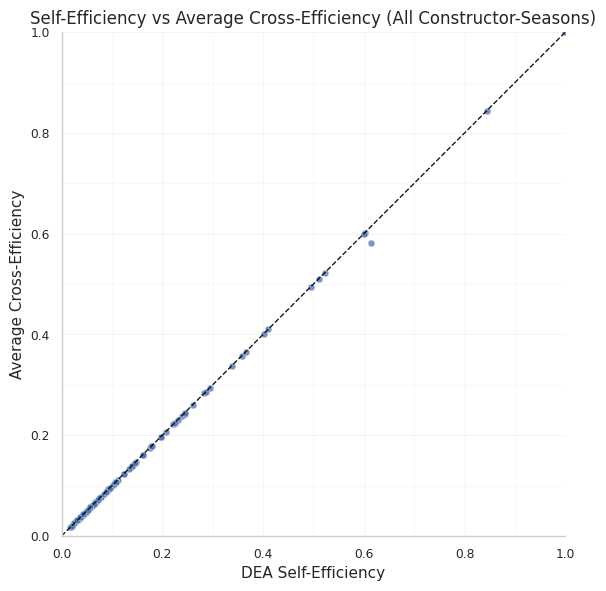

   > Saved 'chart6_self_vs_cross_efficiency.png'
   > Chart 1: efficiency trends


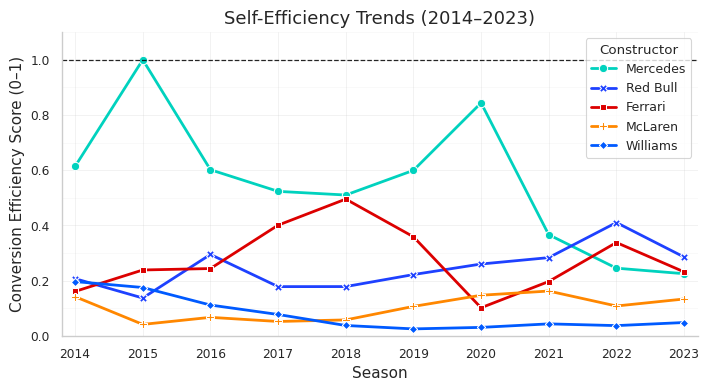

   > Saved 'chart1_efficiency_trends.png'

All charts created.


In [ ]:
print("\n9) Making charts...")

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker

sns.set_theme(style="whitegrid", context="paper")

# -------- Chart 6: self vs cross-efficiency --------
print("   > Chart 6: self vs cross-efficiency")

fig6, ax6 = plt.subplots(figsize=(6, 6))

sns.scatterplot(
    data=dmu_data,
    x="efficiency",
    y="cross_efficiency_avg",
    color="#4C72B0",
    alpha=0.75,
    s=24,
    edgecolor="white",
    linewidth=0.3,
    ax=ax6
)

# 45-degree line
ax6.plot([0, 1], [0, 1], "--", color="black", linewidth=1.0, alpha=0.9)

ax6.set_xlim(0.0, 1.0)
ax6.set_ylim(0.0, 1.0)
ax6.set_aspect("equal", "box")

ax6.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax6.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax6.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax6.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

ax6.grid(which="major", linewidth=0.5, alpha=0.3)
ax6.grid(which="minor", linewidth=0.4, alpha=0.18)

ax6.set_title("Self-Efficiency vs Average Cross-Efficiency (All Constructor-Seasons)",
              fontsize=12)
ax6.set_xlabel("DEA Self-Efficiency", fontsize=11)
ax6.set_ylabel("Average Cross-Efficiency", fontsize=11)

sns.despine(ax=ax6)

plt.tight_layout()
plt.savefig("chart6_self_vs_cross_efficiency.png", dpi=400, bbox_inches="tight")
plt.show()
plt.close(fig6)

print("   > Saved 'chart6_self_vs_cross_efficiency.png'")

# -------- Chart 1: efficiency trends for selected teams --------
print("   > Chart 1: efficiency trends")

# Common F1-style palette for key constructors
teams_to_plot = ["Mercedes", "Red Bull", "Ferrari", "McLaren", "Williams"]
team_colors = {
    "Mercedes": "#00D2BE",   # teal
    "Red Bull": "#1E41FF",   # dark blue
    "Ferrari": "#DC0000",    # red
    "McLaren": "#FF8700",    # papaya
    "Williams": "#005AFF"    # bright blue
}

# filter to these teams and map colours
eff_plot_data = dmu_data[dmu_data["team_name"].isin(teams_to_plot)].copy()
palette = [team_colors[t] for t in teams_to_plot]

fig1, ax1 = plt.subplots(figsize=(7.2, 4.0))

sns.lineplot(
    data=eff_plot_data,
    x="year",
    y="efficiency",
    hue="team_name",
    style="team_name",
    hue_order=teams_to_plot,
    style_order=teams_to_plot,
    markers=True,
    dashes=False,
    linewidth=2,
    markersize=6,
    palette=palette,
    ax=ax1
)

ax1.set_xlim(2013.8, 2023.2)
ax1.set_xticks(range(2014, 2024))

ax1.set_ylim(0.0, 1.1)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

ax1.grid(which="major", linewidth=0.5, alpha=0.35)
ax1.grid(which="minor", axis="y", linewidth=0.4, alpha=0.2)

ax1.axhline(1.0, linestyle="--", linewidth=0.9, color="black", alpha=0.85)

ax1.set_title("Self-Efficiency Trends (2014–2023)", fontsize=13)
ax1.set_xlabel("Season", fontsize=11)
ax1.set_ylabel("Conversion Efficiency Score (0–1)", fontsize=11)

sns.despine(ax=ax1)
ax1.legend(title="Constructor", fontsize=9)

plt.tight_layout()
plt.savefig("chart1_efficiency_trends.png", dpi=400, bbox_inches="tight")
plt.show()
plt.close(fig1)

print("   > Saved 'chart1_efficiency_trends.png'")
print("\nAll charts created.")
